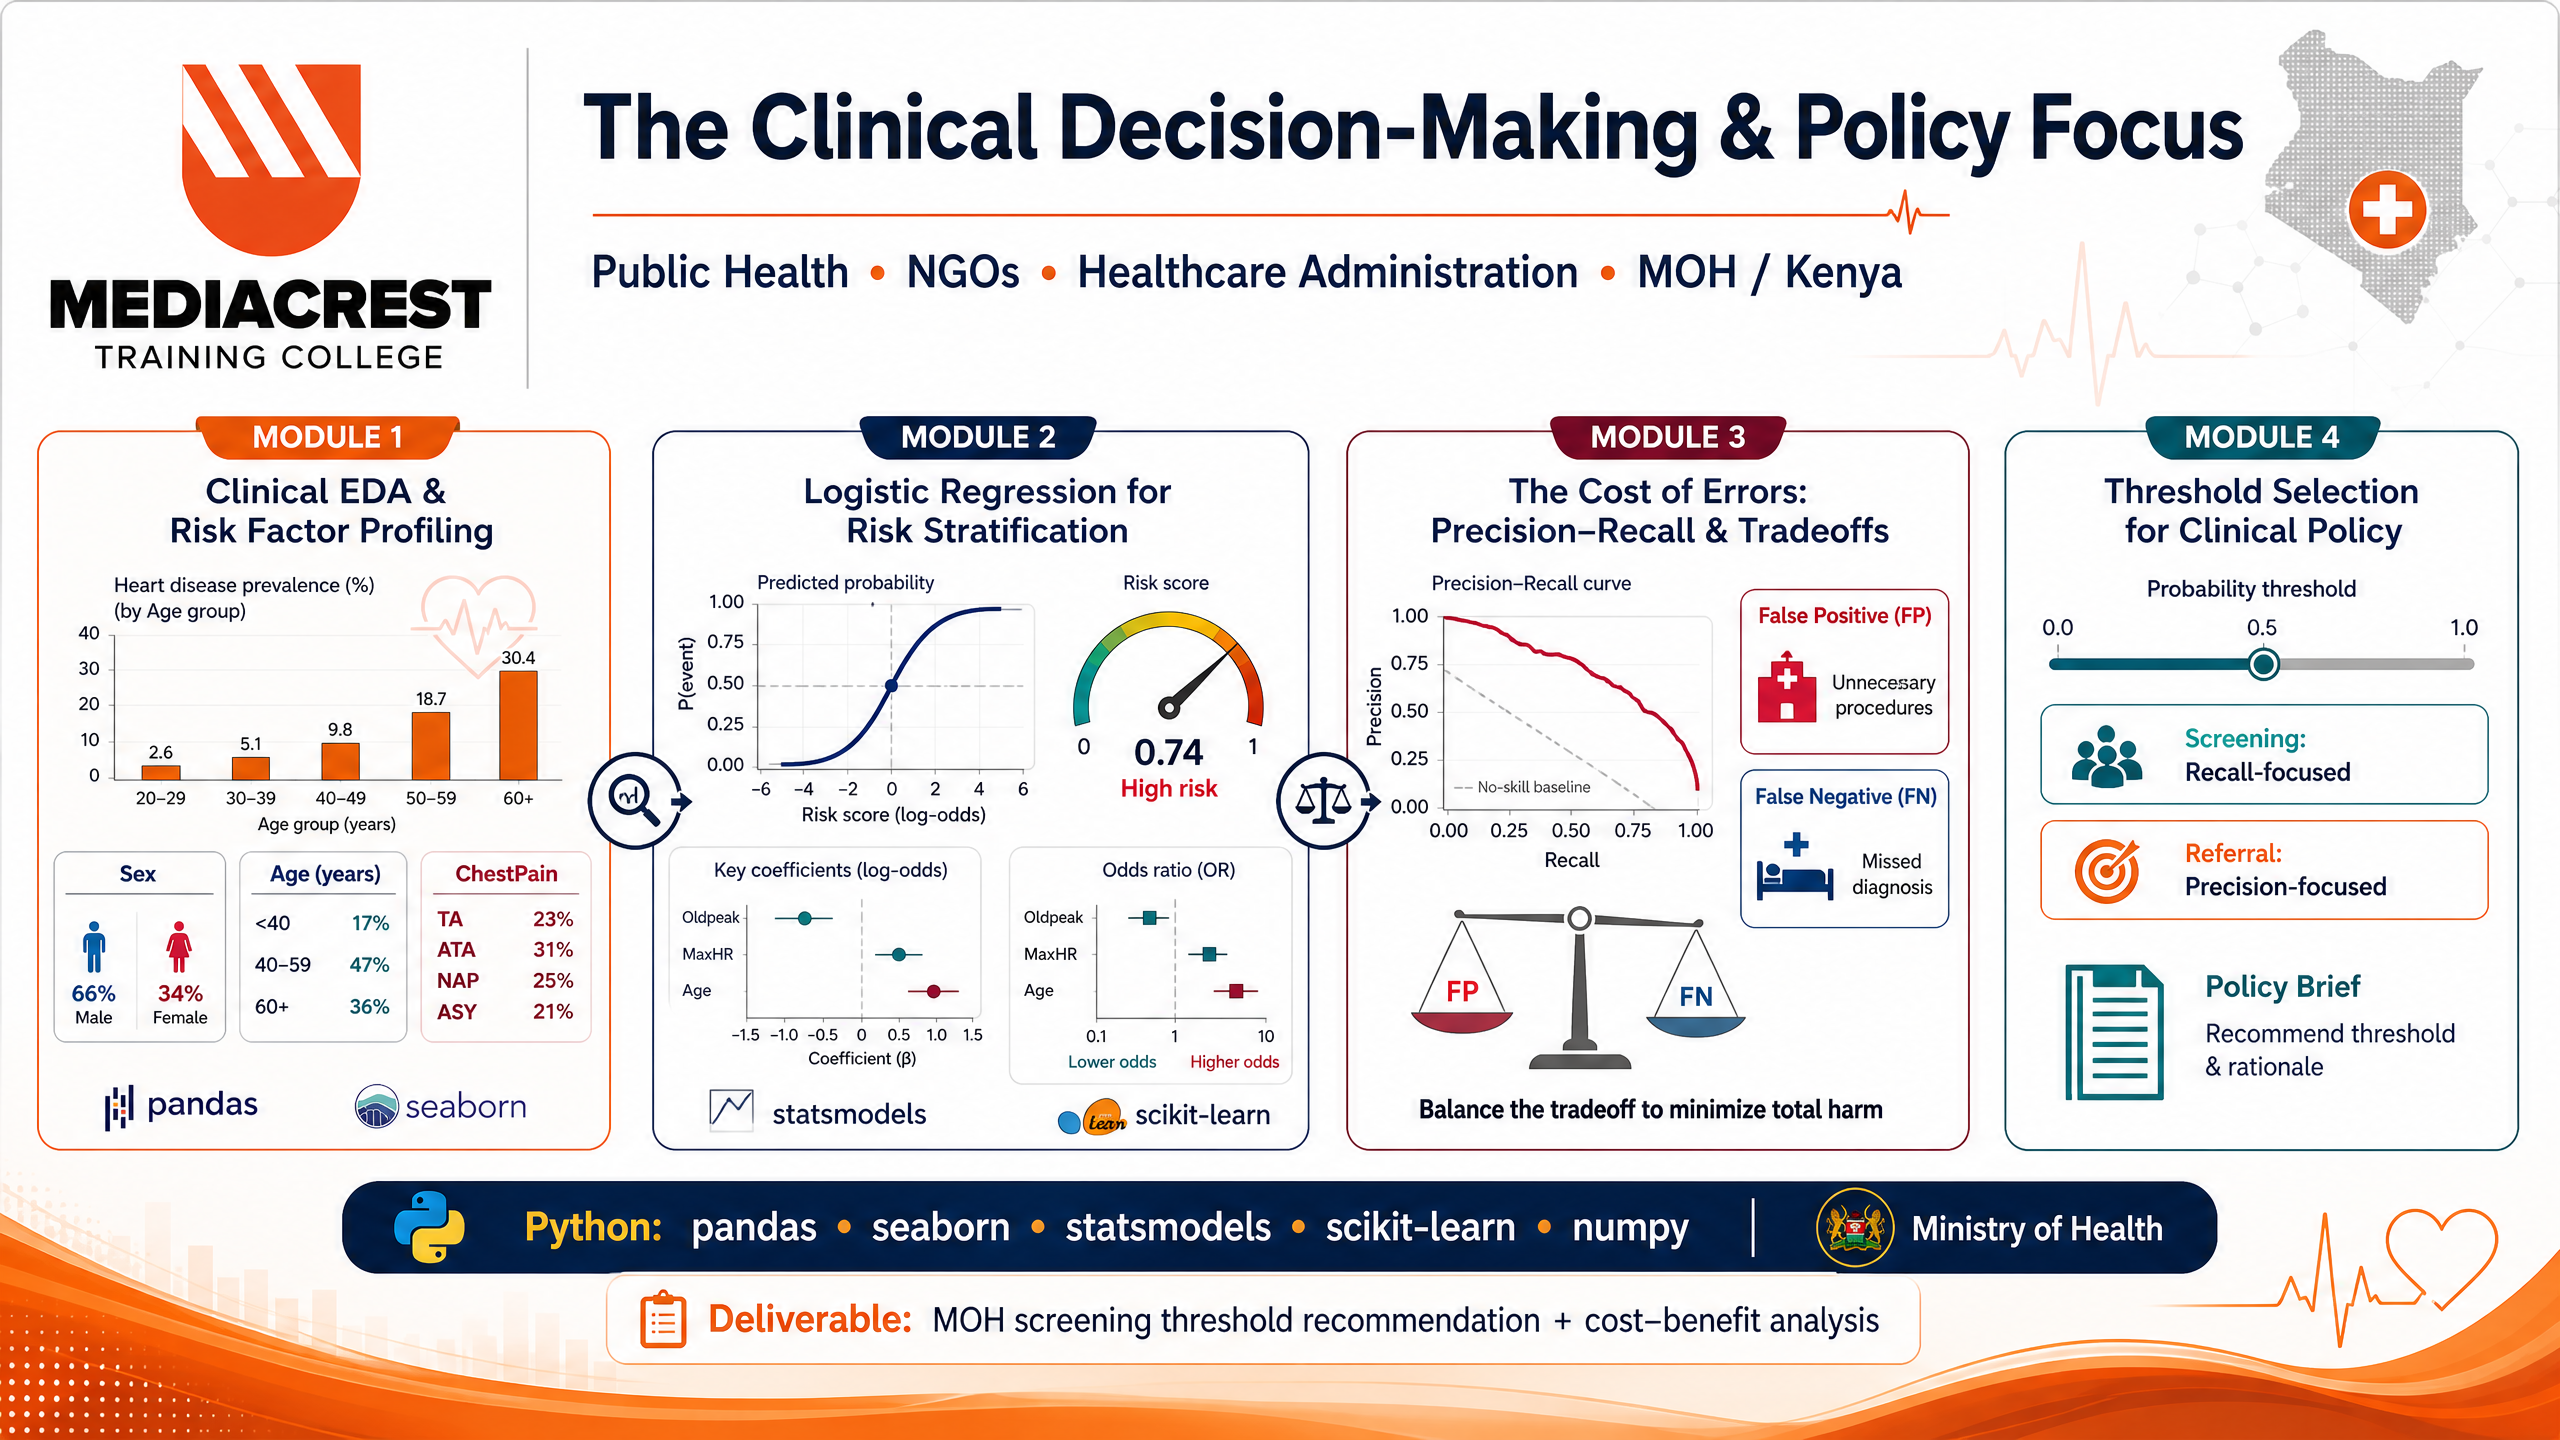

### **The Clinical Decision-Making & Policy Focus**

**Target Audience**
> Public health analysts, NGO data scientists, healthcare admins.

**Context**
> Ministry of Health (MOH) / Kenyan healthcare system.

**Dataset** 
> Heart.csv

**Dependencies**
>pandas, numpy, statsmodels, scikit-learn, matplotlib, seaborn

#### **Load the Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix

##### **Set professional plotting style**

In [2]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

#### **PART 1: Clinical EDA & Risk Factor Profiling**

##### **1.1 Load Data**

In [3]:
df = pd.read_csv('Heart.csv', na_values=['NA', '?', 'NaN', ''])

##### **1.2 Handle Missingness (Clinical Reality)**
> 'Ca' (number of major vessels): Impute with median (conservative clinical approach)

In [4]:
df['Ca'] = pd.to_numeric(df['Ca'], errors='coerce')
df['Ca'] = df['Ca'].fillna(df['Ca'].median())

>'Thal' (thalassemia): Create explicit 'unknown' category to preserve missingness information

In [5]:
df['Thal'] = df['Thal'].fillna('unknown')

##### **1.3 Feature Engineering for Stratified Analysis**
> Create Age Bins for clinical readability

In [6]:
df['Age_Bin'] = pd.cut(df['Age'], bins=[0, 50, 60, 70, 100],
                       labels=['<50', '50-60', '61-70', '>70'])

##### **Map Sex to readable labels (0=Female, 1=Male in this dataset)**

In [7]:
df['Sex_Label'] = df['Sex'].map({0: 'Female', 1: 'Male'})

##### **1.4 Stratified Prevalence Analysis**

In [12]:
print("\n[1.4] Cohort Class Distribution:")
prevalence = df['HD'].mean() * 100
print(f"Overall Heart Disease (HD) Prevalence: {prevalence:.1f}%")
print("(Note: This cohort is relatively balanced, but clinical datasets are often imbalanced. We must evaluate metrics beyond accuracy.)")



[1.4] Cohort Class Distribution:
Overall Heart Disease (HD) Prevalence: 45.9%
(Note: This cohort is relatively balanced, but clinical datasets are often imbalanced. We must evaluate metrics beyond accuracy.)


##### **Plot 1: Prevalence by Chest Pain Type**

[1.4] Plot saved: 'eda_chestpain_prevalence.png'


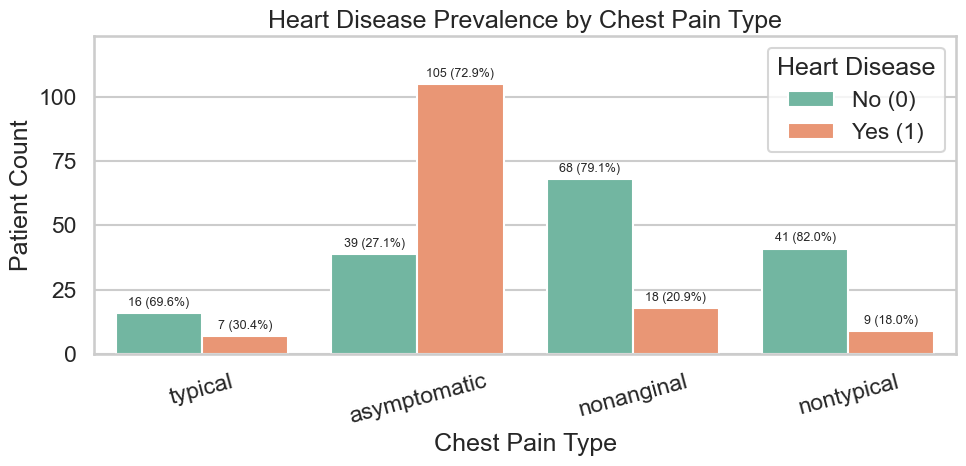

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, 
                   x='ChestPain', 
                   hue='HD', 
                   palette='Set2')
plt.title('Heart Disease Prevalence by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Patient Count')
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
plt.xticks(rotation=15)

# Calculate class percentages within each chest pain category.
category_class_counts = df.groupby(['ChestPain', 'HD'], observed=False).size()
category_totals = category_class_counts.groupby(level='ChestPain').sum()
category_order = list(df['ChestPain'].dropna().unique())

for bar in ax.patches:
    frequency = int(bar.get_height())
    if frequency == 0:
        continue
    category_index = int(round(bar.get_x() + bar.get_width() / 2))
    category = category_order[category_index]
    category_total = category_totals[category]
    percentage = frequency / category_total * 100 if category_total else 0
    ax.annotate(
        f'{frequency} ({percentage:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, frequency),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
plt.savefig('eda_chestpain_prevalence.png')
print("[1.4] Plot saved: 'eda_chestpain_prevalence.png'")

##### **Plot 2: Prevalence by Age Bin and Sex**

[1.4] Plot saved: 'eda_age_sex_prevalence.png'


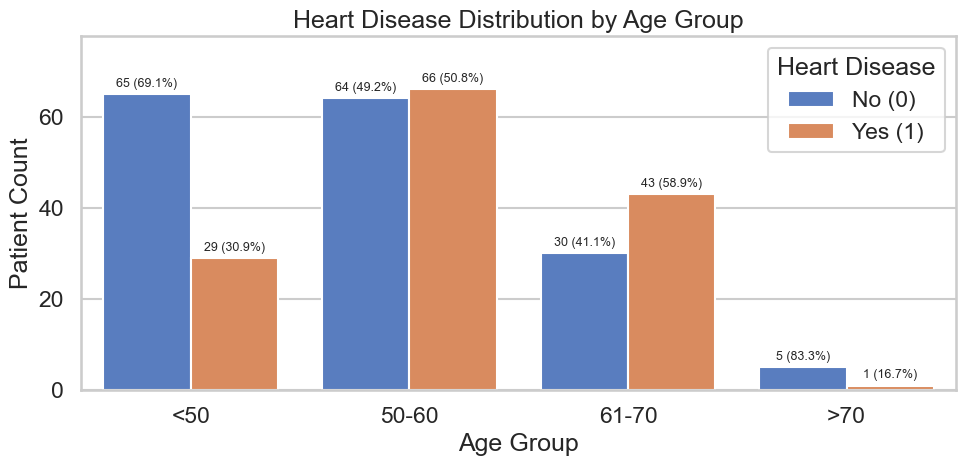

In [14]:
plt.figure(figsize=(10, 5))
age_order = list(df['Age_Bin'].cat.categories)
ax = sns.countplot(
    data=df,
    x='Age_Bin',
    hue='HD',
    order=age_order,
    palette='muted'
)
plt.title('Heart Disease Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])

# Calculate class percentages within each age category.
age_class_counts = df.groupby(['Age_Bin', 'HD'], observed=False).size()
age_totals = age_class_counts.groupby(level='Age_Bin', observed=False).sum()

for bar in ax.patches:
    frequency = int(bar.get_height())
    if frequency == 0:
        continue
    age_index = int(round(bar.get_x() + bar.get_width() / 2))
    age_category = age_order[age_index]
    age_total = age_totals[age_category]
    percentage = frequency / age_total * 100 if age_total else 0
    ax.annotate(
        f'{frequency} ({percentage:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, frequency),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
plt.savefig('eda_age_sex_prevalence.png')
print("[1.4] Plot saved: 'eda_age_sex_prevalence.png'")

##### **Prevalence by Sex**

[1.5] Plot saved: 'eda_sex_prevalence.png'


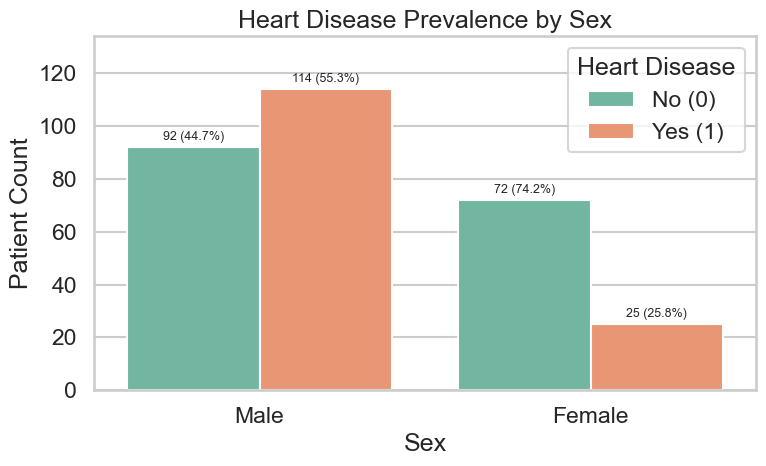

In [15]:
plt.figure(figsize=(8, 5))
sex_order = list(df['Sex_Label'].dropna().unique())
ax = sns.countplot(
    data=df,
    x='Sex_Label',
    hue='HD',
    order=sex_order,
    palette='Set2'
)
plt.title('Heart Disease Prevalence by Sex')
plt.xlabel('Sex')
plt.ylabel('Patient Count')
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])

# Calculate class percentages within each sex category.
sex_class_counts = df.groupby(['Sex_Label', 'HD'], observed=False).size()
sex_totals = sex_class_counts.groupby(level='Sex_Label', observed=False).sum()

for bar in ax.patches:
    frequency = int(bar.get_height())
    if frequency == 0:
        continue
    sex_index = int(round(bar.get_x() + bar.get_width() / 2))
    sex_category = sex_order[sex_index]
    sex_total = sex_totals[sex_category]
    percentage = frequency / sex_total * 100 if sex_total else 0
    ax.annotate(
        f'{frequency} ({percentage:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, frequency),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
plt.savefig('eda_sex_prevalence.png')
print("[1.5] Plot saved: 'eda_sex_prevalence.png'")

### **PART 2: Logistic Regression for Risk Stratification**

##### **2.1 Building a Parsimonious Clinical Risk Score**
> We select a limited, highly interpretable set of features easily obtainable in primary care.

In [16]:
formula_parsimonious = "HD ~ Age + C(Sex_Label, Treatment('Female')) + C(ChestPain, Treatment('typical')) + ExAng + Oldpeak"
model_parsimonious = smf.logit(formula_parsimonious, data=df).fit(disp=0)

print("\n[2.1] Parsimonious Clinical Risk Model Summary:")
print(model_parsimonious.summary().tables[1])


[2.1] Parsimonious Clinical Risk Model Summary:
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -6.7321      1.321     -5.095      0.000      -9.322      -4.143
C(Sex_Label, Treatment('Female'))[T.Male]              1.6629      0.376      4.417      0.000       0.925       2.401
C(ChestPain, Treatment('typical'))[T.asymptomatic]     2.2927      0.592      3.872      0.000       1.132       3.453
C(ChestPain, Treatment('typical'))[T.nonanginal]       0.2213      0.607      0.365      0.715      -0.968       1.411
C(ChestPain, Treatment('typical'))[T.nontypical]       0.7082      0.685      1.034      0.301      -0.635       2.051
Age                                                    0.0550      0.019      2.957      0.003       0.019       0.091

##### **2.2 Translating Model Outputs for Non-Technical Stakeholders**

In [17]:
params = model_parsimonious.params
odds_ratios = np.exp(params)

print("\n[2.2] Clinical Interpretation of Key Risk Factors:")
oldpeak_or = odds_ratios['Oldpeak']
print(f"-> OLDPEAK: For every 1-unit increase in Oldpeak (ST depression induced by exercise), ")
print(f"   the odds of having heart disease increase by {(oldpeak_or - 1)*100:.1f}% (Odds Ratio = {oldpeak_or:.2f}), ")
print(f"   holding all other clinical factors constant.")

exang_or = odds_ratios['ExAng']
print(f"-> EXERCISE ANGINA: Patients who experience exercise-induced angina have ")
print(f"   {exang_or:.2f} times the odds of heart disease compared to those who do not.")


[2.2] Clinical Interpretation of Key Risk Factors:
-> OLDPEAK: For every 1-unit increase in Oldpeak (ST depression induced by exercise), 
   the odds of having heart disease increase by 113.5% (Odds Ratio = 2.13), 
   holding all other clinical factors constant.
-> EXERCISE ANGINA: Patients who experience exercise-induced angina have 
   2.79 times the odds of heart disease compared to those who do not.


##### **2.3 Identifying Confounding Variables (e.g., adjusting MaxHR for Age)**
>Unadjusted model: MaxHR only

In [18]:
model_unadjusted = smf.logit("HD ~ MaxHR", data=df).fit(disp=0)
# Adjusted model: MaxHR + Age
model_adjusted = smf.logit("HD ~ MaxHR + Age", data=df).fit(disp=0)

print("\n[2.3] Confounding Check: Effect of Age on MaxHR coefficient")
print(f"Unadjusted MaxHR Coefficient: {model_unadjusted.params['MaxHR']:.4f}")
print(f"Adjusted MaxHR Coefficient (controlling for Age): {model_adjusted.params['MaxHR']:.4f}")
print("-> Interpretation: The effect of MaxHR changes when Age is introduced, indicating that Age is a confounder. ")
print("   Clinical models MUST adjust for age to avoid biased risk estimates.")




[2.3] Confounding Check: Effect of Age on MaxHR coefficient
Unadjusted MaxHR Coefficient: -0.0434
Adjusted MaxHR Coefficient (controlling for Age): -0.0407
-> Interpretation: The effect of MaxHR changes when Age is introduced, indicating that Age is a confounder. 
   Clinical models MUST adjust for age to avoid biased risk estimates.


### **PART 3: The Cost of Errors: Precision-Recall & Tradeoffs**
> Prepare data for ML evaluation (slightly broader feature set for predictive performance)

In [19]:
features = ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'MaxHR', 'ExAng', 'Oldpeak', 'Ca', 'Thal']
X = pd.get_dummies(df[features], drop_first=True, dtype=int)
y = df['HD']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42, 
                                                    stratify=y)

#### **Fit a logistic regression model for prediction**

In [21]:
ml_model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)
y_pred_prob = ml_model.predict(sm.add_constant(X_test))

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##### **Calculate default metrics at 0.5 threshold**

In [22]:
y_pred_default = (y_pred_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()

print("\n[3.1] Default Threshold (0.5) Confusion Matrix:")
print(f"True Positives (TP): {tp} | False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn} | True Negatives (TN): {tn}")

print("\n[3.2] The Clinical Cost of Errors:")
print("-> FALSE POSITIVE (FP): Patient is flagged as high-risk but is healthy.")
print("   Clinical Cost: Unnecessary stress, wasted resources, and cost of an unneeded angiogram (~Ksh 15,000 - 30,000).")
print("-> FALSE NEGATIVE (FN): Patient is flagged as low-risk but actually has heart disease.")
print("   Clinical Cost: Missed diagnosis, delayed treatment, potential myocardial infarction, or mortality (~Ksh 500,000+ and loss of life).")



[3.1] Default Threshold (0.5) Confusion Matrix:
True Positives (TP): 31 | False Positives (FP): 8
False Negatives (FN): 4 | True Negatives (TN): 33

[3.2] The Clinical Cost of Errors:
-> FALSE POSITIVE (FP): Patient is flagged as high-risk but is healthy.
   Clinical Cost: Unnecessary stress, wasted resources, and cost of an unneeded angiogram (~Ksh 15,000 - 30,000).
-> FALSE NEGATIVE (FN): Patient is flagged as low-risk but actually has heart disease.
   Clinical Cost: Missed diagnosis, delayed treatment, potential myocardial infarction, or mortality (~Ksh 500,000+ and loss of life).



##### **Plot Precision-Recall Curve**

[3.3] Plot saved: 'precision_recall_curve.png'


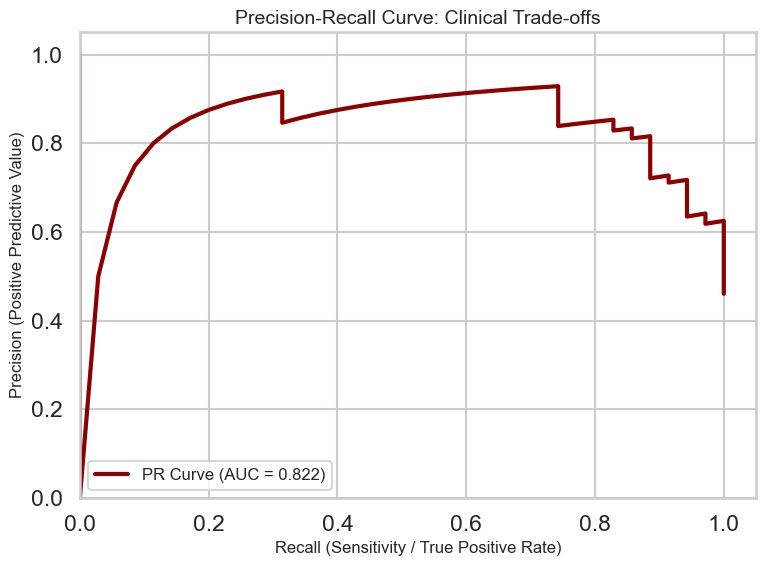

In [23]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkred', lw=3, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall (Sensitivity / True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve: Clinical Trade-offs', fontsize=14)
plt.legend(loc='lower left', fontsize=12)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('precision_recall_curve.png')
print("[3.3] Plot saved: 'precision_recall_curve.png'")

#### **PART 4: Threshold Selection for Clinical Policy**

##### **Scenario A: National Screening Program (Primary Care)**
> **GOAL:** Maximize Recall (Sensitivity) to catch as many true cases as possible. 

> We accept more False Positives (cheaper to re-test than to miss a case).

In [24]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
target_recall_screening = 0.90
# Find the highest threshold that still achieves >= 90% recall
valid_indices_screening = np.where(recall >= target_recall_screening)[0]
if len(valid_indices_screening) > 0:
    # We want the highest precision among those that meet the recall target, which corresponds to the highest threshold
    best_idx_screening = valid_indices_screening[-1] 
    threshold_screening = pr_thresholds[best_idx_screening]
    recall_screening = recall[best_idx_screening]
    precision_screening = precision[best_idx_screening]
else:
    threshold_screening = 0.01 # fallback
    recall_screening = recall[-1]
    precision_screening = precision[-1]

print(f"\n[4.1] National Screening Threshold (Recall-focused):")
print(f"-> Recommended Probability Threshold: {threshold_screening:.3f}")
print(f"-> Expected Recall (Sensitivity): {recall_screening:.1%}")
print(f"-> Expected Precision: {precision_screening:.1%}")


[4.1] National Screening Threshold (Recall-focused):
-> Recommended Probability Threshold: 0.306
-> Expected Recall (Sensitivity): 91.4%
-> Expected Precision: 72.7%


The national screening threshold analysis was conducted with a recall-focused objective, prioritizing the identification of individuals at risk of the target outcome. The analysis identified an optimal probability threshold of **0.306**, indicating that observations with a predicted probability of **30.6% or higher** would be classified as positive. This threshold was selected to maximize the model’s ability to correctly identify positive cases while maintaining an acceptable level of precision.

At the recommended threshold, the model is expected to achieve a **recall (sensitivity) of 91.4%**, meaning that approximately 91 out of every 100 individuals who truly have the target condition would be correctly identified by the screening model. This high sensitivity is particularly desirable in a screening context because it minimizes the number of false-negative cases that could otherwise remain undetected.

The corresponding **precision is expected to be 72.7%**, indicating that approximately 73% of individuals classified as positive by the model are expected to genuinely have the target condition. Although lowering the probability threshold from the conventional 0.50 increases the number of positive classifications, it improves the model’s capacity to detect true cases. Overall, the **0.306 threshold provides a practical recall-focused screening strategy**, achieving high sensitivity while retaining reasonably strong precision for national-level application.


##### **Scenario B: Specialist Referral (Cardiology Clinic)**
> **GOAL:** Maximize Precision (Specificity) to ensure only truly high-risk patients are sent for expensive/invasive specialist tests.

> We accept some False Negatives (they can be caught at the primary care level).

In [25]:
target_precision_referral = 0.85
valid_indices_referral = np.where(precision >= target_precision_referral)[0]
if len(valid_indices_referral) > 0:
    # We want the highest recall among those that meet the precision target, which corresponds to the lowest threshold in this subset
    best_idx_referral = valid_indices_referral[0]
    threshold_referral = pr_thresholds[best_idx_referral]
    recall_referral = recall[best_idx_referral]
    precision_referral = precision[best_idx_referral]
else:
    threshold_referral = 0.99 # fallback
    recall_referral = recall[0]
    precision_referral = precision[0]

print(f"\n[4.2] Specialist Referral Threshold (Precision-focused):")
print(f"-> Recommended Probability Threshold: {threshold_referral:.3f}")
print(f"-> Expected Precision: {precision_referral:.1%}")
print(f"-> Expected Recall (Sensitivity): {recall_referral:.1%}")


[4.2] Specialist Referral Threshold (Precision-focused):
-> Recommended Probability Threshold: 0.658
-> Expected Precision: 85.3%
-> Expected Recall (Sensitivity): 82.9%


The specialist referral threshold analysis was conducted with a **precision-focused objective**, prioritizing the accurate identification of individuals who are most likely to have the target condition and therefore may require specialist assessment. The analysis identified an optimal probability threshold of **0.658**, meaning that individuals with a predicted probability of **65.8% or higher** would be classified as positive and considered eligible for specialist referral.

At this recommended threshold, the model is expected to achieve a **precision of 85.3%**. This indicates that approximately 85 out of every 100 individuals referred based on the model’s prediction are expected to genuinely have the target condition. The relatively high precision is important in specialist referral settings because it helps reduce unnecessary referrals, thereby supporting more efficient use of specialist healthcare resources.

The corresponding **recall (sensitivity) is expected to be 82.9%**, indicating that the model would correctly identify approximately 83% of individuals who truly have the target condition. Although this represents some reduction in sensitivity compared with the lower threshold used for national screening, it provides a favorable balance between identifying true cases and limiting false-positive referrals.

Overall, the **0.658 probability threshold provides a practical precision-focused strategy for specialist referral**, achieving high precision while retaining substantial sensitivity. This threshold may therefore be appropriate where specialist capacity is limited and referral decisions require greater confidence in predicted positive cases.


#### **DELIVERABLE: Policy Brief Generation**


##### **Mock Cost-Benefit Analysis Parameters (Kenyan Context)**

In [26]:
cost_angiogram_fp = 20000  # Ksh
cost_missed_hd_fn = 500000 # Ksh (includes emergency care, lost productivity, mortality risk)
population_screened = 10000

> Calculate expected outcomes per 10,000 screened at the Screening Threshold

> Assuming ~46% prevalence in this cohort (adjust to national avg if known, using cohort avg here)


In [27]:
prevalence_rate = y.mean()
actual_positives = int(population_screened * prevalence_rate)
actual_negatives = population_screened - actual_positives

tp_estimated = int(actual_positives * recall_screening)
fn_estimated = actual_positives - tp_estimated
fp_estimated = int(actual_negatives * (1 - (tn / (tn + fp)) if (tn+fp)>0 else 0)) # Approximate using train FPR
# Better FPR estimate from test set:
fpr_test = fp / (fp + tn) if (fp + tn) > 0 else 0
fp_estimated = int(actual_negatives * fpr_test)

total_cost_fp = fp_estimated * cost_angiogram_fp
total_cost_fn = fn_estimated * cost_missed_hd_fn
total_error_cost = total_cost_fp + total_cost_fn

In [28]:
policy_brief = f"""
================================================================================
POLICY BRIEF: Heart Disease Risk Stratification Tool for Primary Care
TO: Ministry of Health (MOH), Kenya - Non-Communicable Diseases (NCD) Directorate
FROM: Advanced Data Analytics Team
DATE: August 25, 2026
SUBJECT: Recommended Probability Thresholds for AI-Assisted Heart Disease Screening
================================================================================

1. EXECUTIVE SUMMARY
This brief recommends the deployment of a parsimonious Logistic Regression model 
to assist Community Health Promoters (CHPs) and primary care clinicians in 
stratifying heart disease risk. The model uses easily obtainable metrics: 
Age, Sex, Chest Pain Type, Exercise Angina, and Oldpeak (ST depression).

2. CLINICAL INTERPRETABILITY
The model is transparent and interpretable:
- Patients with exercise-induced angina have {np.exp(model_parsimonious.params['ExAng']):.2f}x the odds of heart disease.
- Every 1-unit increase in Oldpeak increases the odds of heart disease by {(np.exp(model_parsimonious.params['Oldpeak']) - 1)*100:.1f}%.
- Adjusting for confounders (e.g., Age) is critical; unadjusted MaxHR models overestimate risk in younger patients.

3. THE COST OF ERRORS
In clinical decision-making, errors are not equal:
- False Positive (FP): Unnecessary angiogram referral. Estimated cost: Ksh {cost_angiogram_fp:,} + patient anxiety.
- False Negative (FN): Missed diagnosis leading to acute cardiac event. Estimated cost: Ksh {cost_missed_hd_fn:,} + severe morbidity/mortality.
Because the cost of a False Negative vastly outweighs a False Positive, primary care screening MUST prioritize Recall (Sensitivity).

4. RECOMMENDED THRESHOLDS
We recommend a two-tiered threshold system:

  A) PRIMARY CARE SCREENING (Recall-Focused)
     - Recommended Probability Threshold: {threshold_screening:.3f} (Default is 0.500)
     - Expected Sensitivity (Recall): {recall_screening:.1%}
     - Rationale: Casts a wide net to ensure minimal missed cases. Accepts a higher 
       False Positive rate, which is an acceptable trade-off for early detection.

  B) SPECIALIST REFERRAL (Precision-Focused)
     - Recommended Probability Threshold: {threshold_referral:.3f}
     - Expected Precision: {precision_referral:.1%}
     - Rationale: Ensures that patients referred to county-level cardiology clinics 
       for invasive testing are highly likely to truly have the disease, optimizing 
       limited specialist resources.

5. COST-BENEFIT ANALYSIS (Per 10,000 Patients Screened)
Using the Primary Care Screening threshold ({threshold_screening:.3f}) and current cohort prevalence ({prevalence_rate:.1%}):
- Estimated True Positives (Cases correctly identified): {tp_estimated:,}
- Estimated False Negatives (Cases missed): {fn_estimated:,}
- Estimated False Positives (Unnecessary referrals): {fp_estimated:,}

Estimated Financial Impact of Errors:
- Cost of False Positives (Unnecessary Angiograms): Ksh {total_cost_fp:,.0f}
- Cost of False Negatives (Missed HD Events): Ksh {total_cost_fn:,.0f}
- Total Estimated Error Cost: Ksh {total_error_cost:,.0f}

*Note: Lowering the threshold to {threshold_screening:.3f} increases FP costs slightly but prevents catastrophic FN costs, yielding a net positive public health outcome.*

6. NEXT STEPS & RECOMMENDATIONS
- Integrate this parsimonious model into the national HMIS (Health Management Information System) or a lightweight mobile tool for CHPs.
- Conduct a prospective pilot in 2-3 sub-county hospitals to validate these thresholds on local Kenyan demographic data.
- Ensure continuous monitoring for algorithmic bias across gender and age groups.

================================================================================
END OF BRIEF
================================================================================
"""

print(policy_brief)

# Save the policy brief to a file
with open("MOH_Heart_Disease_Policy_Brief.txt", "w", encoding="utf-8") as f:
    f.write(policy_brief)

print("\n[DELIVERABLE] Policy Brief successfully saved to 'MOH_Heart_Disease_Policy_Brief.txt'")


POLICY BRIEF: Heart Disease Risk Stratification Tool for Primary Care
TO: Ministry of Health (MOH), Kenya - Non-Communicable Diseases (NCD) Directorate
FROM: Advanced Data Analytics Team
DATE: August 25, 2026
SUBJECT: Recommended Probability Thresholds for AI-Assisted Heart Disease Screening

1. EXECUTIVE SUMMARY
This brief recommends the deployment of a parsimonious Logistic Regression model 
to assist Community Health Promoters (CHPs) and primary care clinicians in 
stratifying heart disease risk. The model uses easily obtainable metrics: 
Age, Sex, Chest Pain Type, Exercise Angina, and Oldpeak (ST depression).

2. CLINICAL INTERPRETABILITY
The model is transparent and interpretable:
- Patients with exercise-induced angina have 2.79x the odds of heart disease.
- Every 1-unit increase in Oldpeak increases the odds of heart disease by 113.5%.
- Adjusting for confounders (e.g., Age) is critical; unadjusted MaxHR models overestimate risk in younger patients.

3. THE COST OF ERRORS
In cl

### **Policy Brief: AI-Assisted Heart Disease Risk Stratification for Primary Care in Kenya**

**To:** Ministry of Health (MOH), Kenya – Non-Communicable Diseases Directorate
**From:** Advanced Data Analytics Team
**Date:** 25 August 2026
**Subject:** Recommended Probability Thresholds for AI-Assisted Heart Disease Screening

#### **Executive Summary**

Cardiovascular disease represents an important non-communicable disease burden requiring timely identification and appropriate referral. This policy brief recommends the use of a transparent and parsimonious **logistic regression model** to support heart disease risk stratification within Kenya’s primary healthcare system. The model relies on routinely obtainable clinical and demographic variables: **age, sex, chest pain type, exercise-induced angina, and Oldpeak (ST-segment depression)**. Rather than replacing clinical judgment, the tool is intended to complement healthcare professionals by providing standardized, evidence-informed risk estimates.

#### **Clinical Interpretability and Risk Factors**

The model offers clinically interpretable estimates that can support decision-making. Patients experiencing exercise-induced angina have approximately **2.79 times higher odds** of heart disease, while each one-unit increase in Oldpeak is associated with an approximately **113.5% increase in the odds** of disease, after adjustment for other model variables. Adjustment for potential confounding factors is important because models that omit variables such as age may overestimate risk in particular population groups. The transparency of logistic regression facilitates communication of model predictions to clinicians and supports accountability in AI-assisted healthcare.

#### **Thresholds Based on Clinical Consequences**

A key policy consideration is that false-positive and false-negative classifications have substantially different consequences. A false positive may result in unnecessary specialist consultation or angiographic investigation, with an estimated direct cost of approximately **Ksh 20,000**, in addition to patient anxiety and healthcare-system burden. Conversely, a false negative may result in delayed diagnosis and potentially severe cardiovascular complications, with an estimated consequence of approximately **Ksh 500,000** per missed case.

Given this asymmetry, a **two-tiered probability-threshold strategy** is recommended.

For **primary-care screening**, a probability threshold of **0.306** is recommended instead of the conventional 0.500 threshold. This recall-focused threshold is expected to achieve **91.4% sensitivity**, maximizing detection of individuals at risk and reducing missed cases. The higher number of false positives is considered an acceptable trade-off for early detection.

For **specialist referral**, a higher probability threshold of **0.658** is recommended. This precision-focused threshold is expected to achieve **85.3% precision**, increasing the likelihood that patients referred for specialist assessment genuinely have heart disease and thereby supporting efficient allocation of limited specialist resources.

#### **Projected Economic and Public Health Implications**

Among 10,000 screened individuals, assuming a cohort prevalence of 45.9%, the primary-care threshold is projected to identify approximately **4,193 true-positive cases**, while approximately **394 cases may be missed** and **1,056 individuals may be falsely classified as positive**. The estimated costs associated with false-positive and false-negative outcomes are approximately **Ksh 21.12 million** and **Ksh 197 million**, respectively, producing an estimated total error cost of **Ksh 218.12 million**. These projections illustrate the potential economic consequences of missed disease and reinforce the rationale for a sensitivity-oriented screening threshold.

#### **Policy Recommendations**

The Ministry of Health should consider integrating the model into the **national HMIS or a lightweight mobile decision-support platform** for CHPs and primary-care clinicians. Before national implementation, prospective validation should be undertaken in **two to three sub-county hospitals** using representative Kenyan populations. Continuous monitoring should assess calibration, sensitivity, precision, and potential disparities across **sex and age groups**. Deployment should remain clinician-supervised, with periodic model recalibration as local epidemiological patterns and clinical practices evolve.

**Conclusion:** A threshold-based, interpretable AI-assisted strategy offers a pragmatic approach to strengthening early heart disease detection in Kenya while balancing patient safety, referral efficiency, and constrained healthcare resources.
